In [42]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from itertools import product
import json

from datetime import datetime
import os
import h5py
import shutil

import importlib

import qt_qubit_sys
importlib.reload(qt_qubit_sys)
from qt_qubit_sys import *

Use Josh's algorithm for simulating ramp dephasing

In [43]:
# # 1, 4, 5, 8
# Q8_couplings_3m = {(1,2):-5.2e-3, (2,3):-5.3e-3, (3,4):-4.5e-3, (4,5):-4.7e-3, (5,6):-4.5e-3, (6,7):-5.1e-3, (7,8):-5.3e-3,
#                                (1,3):-17.3e-3, (2,4):-17.5e-3, (3,5):-17.5e-3, (4,6):-17.5e-3, (5,7):-17.4e-3, (6,8):-17.3e-3}

# ramp_shape = simple_ramp
# T = 290
# init_ff = np.array([0, -0.1, -0.1, 0, 0, -0.1, -0.1, 0]) * 1.5
# # init_ff = -np.array(init_ff)
# expt_ff = [0,0,0,0,0,0,0,0]
# Q8_3m = M_qubit_sys_reduced(w=[0,0,0,0,0,0,0,0], U= [200.e-3]*8,
#                 couplings=Q8_couplings_3m,
#                          time_deps = {1: ramp_shape(init_ff[0],expt_ff[0], T),
#                                       2: ramp_shape(init_ff[1],expt_ff[1], T),
#                                       3: ramp_shape(init_ff[2],expt_ff[2], T),
#                                       4: ramp_shape(init_ff[3],expt_ff[3], T),
#                                       5: ramp_shape(init_ff[4],expt_ff[4], T),
#                                       6: ramp_shape(init_ff[5],expt_ff[5], T),
#                                       7: ramp_shape(init_ff[6],expt_ff[6], T),
#                                       8: ramp_shape(init_ff[7],expt_ff[7], T)},
#                          T2s=[2.085e3, 0.581e3, 1.976e3, 0.366e3, 2.119e3, 2.005e3, 1.727e3, 1.792e3],
#                     RWA=True, N=5, reduce_Hamil_to_n=4)
# prep_state = Q8_3m.reduce_ket(Q8_3m.fock([1,0,0,1,1,0,0,1]))
# print(qt.expect(Q8_3m.num_ops, prep_state))

# tlist = np.linspace(0, T, 15)
# res = Q8_3m.mesolve(prep_state, tlist, options={'store_states':True}, plot=True)

# final_state = res.states[-1]
# overlap = np.abs(final_state.overlap(Q8_3m.eigstates(4)[-1]))
# corr = qt.expect(Q8_3m.Jcorr((2,1),(4,3)), final_state)
# print(overlap, corr)

# 1. Extract Config Data

In [44]:
coupling_point = 'coupling_point_6'
coupling_point = 'coupling_point_2_retake'
# coupling_point = 'coupling_point_5_retake'
eigenstate = 'highest'

In [45]:
config_filename = '../current_correlations/current_correlations_config.json'

with open(config_filename, 'r') as f:
    config = json.load(f)

print(config.keys())

if coupling_point in config:
    coupling_point_config = config[coupling_point]
else:
    bond_order_config_filename = '../bond_order_parameter/bond_order_config.json'
    with open(bond_order_config_filename, 'r') as f:
        bond_order_config = json.load(f)
        coupling_point_config = bond_order_config[coupling_point]




print(coupling_point_config.keys())


dict_keys(['coupling_point_1', 'coupling_point_2', 'coupling_point_3', 'coupling_point_4', 'coupling_point_5', 'coupling_point_6', 'coupling_point_5_retake', 'coupling_point_6_retake'])
dict_keys(['coupling', 'data_config', 'simulation_config', 'T2s'])


In [46]:
# extract parameters

num_levels = coupling_point_config['simulation_config']['num_levels']
num_qubits = coupling_point_config['simulation_config']['num_qubits']
num_particles = coupling_point_config['simulation_config']['num_particles']

U = coupling_point_config['simulation_config']['U'] * 2 * np.pi


T1 = coupling_point_config['simulation_config']['T1']
T2 = coupling_point_config['simulation_config']['T2']


coupling_dict = coupling_point_config['coupling']

ramp_time = coupling_point_config['simulation_config']['ramp_time']

J = []
J_parallel = []

for i in range(num_qubits):
    if i < num_qubits - 1:
        J.append(coupling_dict[f'J_{i+1}{i+2}'.format(i)])

    if i < num_qubits - 2:
        J_parallel.append(coupling_dict[f'J_{i+1}{i+3}'])

J = np.array(J) * 2 * np.pi
J_parallel = np.array(J_parallel) * 2 * np.pi

T2_real = []
T2_dict = coupling_point_config['T2s']
for i in range(num_qubits):
    T2_real.append(T2_dict[f'T2_{i+1}'])

# convert T2_real to ns
T2_real = np.array(T2_real) * 1e3  # ns


In [47]:
# define couplings

# Josh's parameters are defined without 2 pi
# convert to GHz also

Q8_couplings_3m = {}

for i in range(num_qubits - 1):
    Q8_couplings_3m[(i+1,i+2)] = J[i]/1e3/2/np.pi

for i in range(num_qubits - 2):
    Q8_couplings_3m[(i+1,i+3)] = J_parallel[i]/1e3/2/np.pi

# define interaction strengths, Josh defines Hamiltonian with -U/2 adag a, so use the negative of U
# and convert to GHz
U_list = [-U/1e3/2/np.pi] * num_qubits

In [48]:

# ramp_shape = simple_ramp

# ramp_time_ns = ramp_time * 1e3

# if eigenstate == 'highest':
#      init_ff = np.array([0, -0.1, -0.1, 0, 0, -0.1, -0.1, 0]) * 1.5
# elif eigenstate == 'lowest':
#      init_ff = np.array([0, 0.1, 0.1, 0, 0, 0.1, 0.1, 0]) * 1.5

# expt_ff = [0,0,0,0,0,0,0,0]

# T2 = 2e3 # ns
# T2_list = [T2]*num_qubits

# # # T2_real = [2.085e3, 0.581e3, 1.976e3, 0.366e3, 2.119e3, 2.005e3, 1.727e3, 1.792e3]

# use_real_T2s = False
# if use_real_T2s:
#     T2_list = T2_real

# Q8_3m = M_qubit_sys_reduced(w=[0]*num_qubits, U=U_list,
#                 couplings=Q8_couplings_3m,
#                          time_deps = {1: ramp_shape(init_ff[0],expt_ff[0], ramp_time_ns),
#                                       2: ramp_shape(init_ff[1],expt_ff[1], ramp_time_ns),
#                                       3: ramp_shape(init_ff[2],expt_ff[2], ramp_time_ns),
#                                       4: ramp_shape(init_ff[3],expt_ff[3], ramp_time_ns),
#                                       5: ramp_shape(init_ff[4],expt_ff[4], ramp_time_ns),
#                                       6: ramp_shape(init_ff[5],expt_ff[5], ramp_time_ns),
#                                       7: ramp_shape(init_ff[6],expt_ff[6], ramp_time_ns),
#                                       8: ramp_shape(init_ff[7],expt_ff[7], ramp_time_ns)},
#                          T2s=T2_list,
#                     RWA=True, N=5, reduce_Hamil_to_n=4)

# prep_state = Q8_3m.reduce_ket(Q8_3m.fock([1,0,0,1,1,0,0,1]))

# print(qt.expect(Q8_3m.num_ops, prep_state))

# print(f'ramp time ns: {ramp_time_ns} ns')
# print(f'U_list: {U_list} GHz')
# print(f'T2_list: {T2_list} ns')

# tlist = np.linspace(0, ramp_time_ns, 15)


In [49]:
# res = Q8_3m.mesolve(prep_state, tlist, options={'store_states':True}, plot=True)

# final_state = res.states[-1]
# overlap = np.abs(final_state.overlap(Q8_3m.eigstates(4)[-1]))
# corr = qt.expect(Q8_3m.Jcorr((2,1),(4,3)), final_state
#                  )
# print(overlap, corr)

Sweep T2

In [50]:
T2s = [0.1, 0.5, 1, 2, 5, 10, 40]
T2s = [10**-n for n in range(2, 5)]

init_ff = np.array([0, -0.1, -0.1, 0, 0, -0.1, -0.1, 0]) * 1.5
expt_ff = [0,0,0,0,0,0,0,0]

exponent_list = list(np.arange(-1, 0.5, 0.25)) + [1, 2]
T2s = [10**n for n in exponent_list]

T2s = [0.01, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 2.0, 5.0, 10.0, 50.0]
T2s = ['real']

print(T2s)



ramp_shape = simple_ramp
ramp_time_ns = ramp_time * 1e3
tlist = np.linspace(0, ramp_time_ns, 15)



final_states = []

for i in range(len(T2s)):


    T2 = T2s[i]

    if T2 == 'real':
        T2_list = T2_real
    else:
        T2_list = [T2*1e3]*num_qubits

    print(T2_list)
    print(type(T2_list))
    print(T2_list.dtype)


    Q8_3m = M_qubit_sys_reduced(w=[0]*num_qubits, U=U_list,
                couplings=Q8_couplings_3m,
                         time_deps = {1: ramp_shape(init_ff[0],expt_ff[0], ramp_time_ns),
                                      2: ramp_shape(init_ff[1],expt_ff[1], ramp_time_ns),
                                      3: ramp_shape(init_ff[2],expt_ff[2], ramp_time_ns),
                                      4: ramp_shape(init_ff[3],expt_ff[3], ramp_time_ns),
                                      5: ramp_shape(init_ff[4],expt_ff[4], ramp_time_ns),
                                      6: ramp_shape(init_ff[5],expt_ff[5], ramp_time_ns),
                                      7: ramp_shape(init_ff[6],expt_ff[6], ramp_time_ns),
                                      8: ramp_shape(init_ff[7],expt_ff[7], ramp_time_ns)},
                         T2s=T2_list,
                    RWA=True, N=5, reduce_Hamil_to_n=4)

    prep_state = Q8_3m.reduce_ket(Q8_3m.fock([1,0,0,1,1,0,0,1]))

    res = Q8_3m.mesolve(prep_state, tlist, options={'store_states':True}, plot=False)

    final_state = res.states[-1]
    final_states.append(final_state)


overlaps = []
true_eigenstate = Q8_3m.eigstates(4)[-1]
for i in range(len(final_states)):
    overlap = np.abs(final_states[i].overlap(true_eigenstate))
    overlaps.append(overlap)


final_states.append(true_eigenstate)
overlaps.append(1)

T2_labels = [str(t2) for t2 in T2s] + ['no_dephasing_ramp']


['real']
[2085.  581. 1976.  366. 2119. 2005. 1727. 1792.]
<class 'numpy.ndarray'>
float64
Reduced 390625^2-dimensional subspace to a 330^2-dimensional one.
[None, None, None, None, None, None, None, None, None]
[  nan 2085.  581. 1976.  366. 2119. 2005. 1727. 1792.]
0.00047961630695443646
0.0017211703958691911
0.0005060728744939271
0.00273224043715847
0.00047192071731949034
0.0004987531172069825
0.0005790387955993051
0.0005580357142857143
15 time steps for 8 qubits and N=5 took 83.96377801895142 seconds to simulate.
Hamiltonian of shape (330, 330) took 0.08212900161743164 seconds to diagonalize.


In [51]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('ramp_state_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)

def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)
    

def print_tree(data, max_level=None):
    def __print_tree_recursive(root, level=0):
        if isinstance(root, dict):
            if not max_level is None and level == max_level:
                return
            level_str = '- '*level
            for key in root:
                print(f'{level_str}{key}')
                __print_tree_recursive(root[key], level+1)
    __print_tree_recursive(data)

In [52]:
print(type(final_states))
print(type(final_states[i]))
print(type(final_states[i].full()))
print(final_states[i].full().shape)

<class 'list'>
<class 'qutip.core.qobj.Qobj'>
<class 'numpy.ndarray'>
(330, 330)


In [53]:
print(T2s)
print(T2_labels)

['real']
['real', 'no_dephasing_ramp']


In [54]:
filename = 'ramp_dephasing_states.h5'

state_dictionary = {T2_labels[i]: final_states[i].full()  for i in range(len(T2_labels))}


keys = (coupling_point, eigenstate)

# update_data_file(filename, state_dictionary, keys=keys, save_backup=True

backup_data(filename)


# delete = False
# if delete:
#     ramp_state_data = load_nested_dict_from_hdf5(filename)
#     new_data = ramp_state_data.copy()
#     if coupling_point in new_data and eigenstate in new_data[coupling_point]:
#         del new_data[coupling_point][eigenstate]
#     save_nested_dict_to_hdf5(filename, new_data, save_backup=False)


for i in range(len(T2_labels)):
    keys = (coupling_point, eigenstate, T2_labels[i])
    update_data_file(filename, final_states[i].full(), keys=keys, save_backup=False)


load data to test

In [55]:
filename = 'ramp_dephasing_states.h5'

ramp_state_data = load_nested_dict_from_hdf5(filename)

print_tree(ramp_state_data, max_level=3)

coupling_point_1
- highest
- - 0.01
- - 0.1
- - 0.2
- - 0.3
- - 0.5
- - 0.8
- - 1.0
- - 10.0
- - 2.0
- - 5.0
- - 50.0
- - no_dephasing_ramp
- - real
coupling_point_2
- highest
- - 0.01
- - 0.1
- - 0.2
- - 0.3
- - 0.5
- - 0.8
- - 1.0
- - 10.0
- - 2.0
- - 5.0
- - 50.0
- - no_dephasing_ramp
- - real
coupling_point_2_retake
- highest
- - no_dephasing_ramp
- - real
coupling_point_3
- highest
- - 0.01
- - 0.1
- - 0.2
- - 0.3
- - 0.5
- - 0.8
- - 1.0
- - 10.0
- - 2.0
- - 5.0
- - 50.0
- - no_dephasing_ramp
- - real
coupling_point_4
- highest
- - no_dephasing_ramp
- - real
coupling_point_5
- highest
- - no_dephasing_ramp
- - real
coupling_point_5_retake
- highest
- - no_dephasing_ramp
- - real
coupling_point_6
- highest
- - no_dephasing_ramp
- - real
coupling_point_6_retake
- highest
- - no_dephasing_ramp
- - real


check purity of all states

no_dephasing_ramp
<class 'numpy.ndarray'>
(330, 1)
T2 = no_dephasing_ramp us, purity = 1.0
real
<class 'numpy.ndarray'>
(330, 330)
T2 = real us, purity = 0.5179749522522986


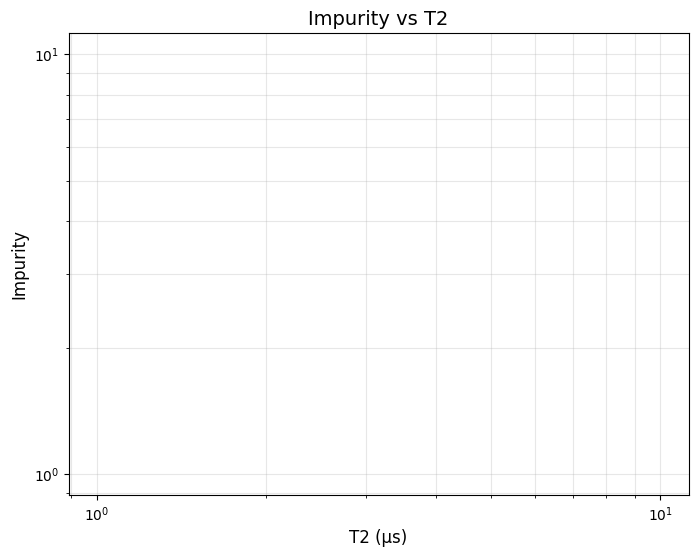

In [56]:
ramp_state_data = load_nested_dict_from_hdf5(filename)

# coupling_point = 'coupling_point_2'
eigenstate = 'highest'

T2s = []
purities = []


for T2 in ramp_state_data[coupling_point][eigenstate]:
    print(T2)
    ramp_state = ramp_state_data[coupling_point][eigenstate][T2]
    print(type(ramp_state))
    print(ramp_state.shape)


    rho_qt = qt.Qobj(ramp_state)
    if rho_qt.isoper:
        purity = (rho_qt**2).tr()
    elif rho_qt.isket:
        purity = 1.0

    print(f'T2 = {T2} us, purity = {purity}')

    try:
        float(T2)
        T2s.append(float(T2))
        purities.append(purity)
    except:
        pass

T2s = np.array(T2s)
purities = np.array(purities)

sorted_indices = np.argsort(T2s)
T2s = T2s[sorted_indices]
purities = purities[sorted_indices]

impurities = 1 - purities
plt.figure(figsize=(8, 6))
plt.loglog(T2s, impurities, 'o-', linewidth=2, markersize=8)
# plt.plot(T2s, impurities, 'o-', linewidth=2, markersize=8)
plt.xlabel('T2 (μs)', fontsize=12)
plt.ylabel('Impurity', fontsize=12)
plt.title('Impurity vs T2', fontsize=14)
plt.grid(True, which='both', alpha=0.3)
plt.show()


T2 		 overlap 	 non-overlap


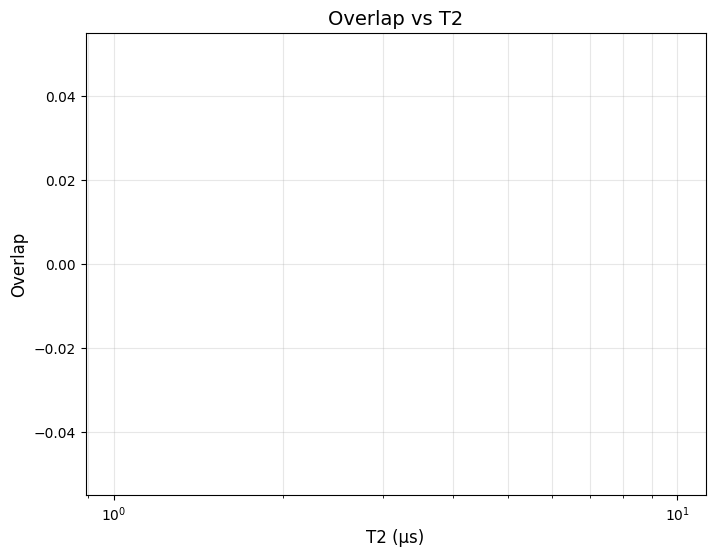

In [57]:
### plot overlaps vs T2s


non_overlap = 1 - np.array(overlaps)

print(f'T2 \t\t overlap \t non-overlap')
for i in range(len(T2s)):    
    print(f'{T2s[i]} us  \t {overlaps[i]:.4f} \t\t {non_overlap[i]:.4f}')


plt.figure(figsize=(8, 6))
# plt.loglog(T2s, non_overlap, 'o-', linewidth=2, markersize=8)
plt.semilogx(T2s, overlaps[:len(T2s)], 'o-', linewidth=2, markersize=8)


plt.xlabel('T2 (μs)', fontsize=12)
plt.ylabel('Overlap', fontsize=12)
plt.title('Overlap vs T2', fontsize=14)
plt.grid(True, which='both', alpha=0.3)
plt.show()